In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sbn
import numpy as np
import statsmodels.api as sm

In [2]:
expr = pd.read_csv('~/local/data/ccle/CCLE_miRNA_20180525.gct', sep='\t', skiprows=2)
expr = expr.drop(columns=['Name']).set_index('Description').T.reset_index().rename(columns={'index': 'CCLE_Name'})

In [3]:
expr.columns[expr.columns.str.contains('miR-101') | expr.columns.str.contains('miR-125b')]

Index(['hsa-miR-101', 'hsa-miR-125b'], dtype='object', name='Description')

In [128]:
target_mirna = 'hsa-miR-342-3p' #'hsa-miR-125b' #'hsa-miR-101' #'hsa-miR-181a'
target_drug = 'BRD-K12343256'

expr = expr[['CCLE_Name', target_mirna]]
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'lineage', 'primary_disease', 'Subtype']].dropna()
expr = expr.merge(cell_info, left_on='CCLE_Name', right_on='CCLE_Name', how='left')
expr = expr.set_index('DepMap_ID')
expr.head() 

,CCLE_Name,hsa-miR-342-3p,lineage,primary_disease,Subtype
DepMap_ID,,,,,
ACH-000698,DMS53_LUNG,114.14,lung,Lung Cancer,Small Cell Lung Cancer (SCLC)
ACH-000489,SW1116_LARGE_INTESTINE,37.10,colorectal,Colon/Colorectal Cancer,Adenocarcinoma
ACH-000431,NCIH1694_LUNG,1233.55,lung,Lung Cancer,Small Cell Lung Cancer (SCLC)
ACH-000707,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,388.18,lymphocyte,Lymphoma,"B-cell, Non-Hodgkins, Burkitts"
ACH-000509,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,730.22,lymphocyte,Lymphoma,"T-cell, Non-Hodgkins, Cutaneous"


In [129]:
resp = pd.read_csv('~/local/data/ccle/sanger-dose-response.csv')
resp = resp[lambda x: x.BROAD_ID == target_drug]
resp.head() 

,DATASET,COSMIC_ID,DRUG_ID,MIN_CONC,MAX_CONC,RMSE_PUBLISHED,Z_SCORE_PUBLISHED,IC50_PUBLISHED,AUC_PUBLISHED,ARXSPAN_ID,DRUG_NAME,BROAD_ID,upper_limit,ec50,slope,lower_limit,auc,log2.ic50,mse,R2
257171,GDSC1,683665,1372,0.003906,1.0,0.119773,0.800808,2.481571,0.957176,ACH-002270,TRAMETINIB,BRD-K12343256,1.256407,0.077573,-0.052521,0.522920,0.891740,NaN,0.000590,0.375831
257172,GDSC1,684052,1372,0.003906,1.0,0.249754,0.423259,0.907994,0.883520,ACH-000052,TRAMETINIB,BRD-K12343256,1.095369,0.251481,-0.071063,0.388402,0.759300,NaN,0.001246,0.319947
257173,GDSC1,684055,1372,0.003906,1.0,0.079643,0.759437,2.222696,0.932690,ACH-002104,TRAMETINIB,BRD-K12343256,0.988113,0.179408,-1.159792,0.787311,0.922274,NaN,0.001470,0.781707
257174,GDSC1,684057,1372,0.003906,1.0,0.036387,1.308943,9.602803,0.968449,ACH-002106,TRAMETINIB,BRD-K12343256,1.046024,0.188491,-0.131159,0.888291,0.972795,NaN,0.000075,0.565207
257175,GDSC1,684059,1372,0.003906,1.0,0.063823,0.741538,2.119239,0.923213,ACH-002108,TRAMETINIB,BRD-K12343256,1.278697,0.376466,-0.129156,0.441299,0.907830,NaN,0.002214,0.552942


In [130]:
df = expr.merge(resp, left_on='DepMap_ID', right_on='ARXSPAN_ID', how='left')
df = df.assign(log_expr=lambda x: np.log2(x[target_mirna] + 1))
df = df.assign(zscore_expr=lambda x: (x.log_expr - x.log_expr.mean()) / x.log_expr.std())
df = df.assign(zscore_auc=lambda x: (x.auc - x.auc.mean()) / x.auc.std())
df.head() 

,CCLE_Name,hsa-miR-342-3p,lineage,primary_disease,Subtype,DATASET,COSMIC_ID,DRUG_ID,MIN_CONC,MAX_CONC,...,ec50,slope,lower_limit,auc,log2.ic50,mse,R2,log_expr,zscore_expr,zscore_auc
0,DMS53_LUNG,114.14,lung,Lung Cancer,Small Cell Lung Cancer (SCLC),GDSC1,907295.0,1372.0,0.003906,1.0,...,0.174463,-4.430746,0.728075,0.905247,NaN,0.000199,0.985504,6.847245,-0.321618,0.727768
1,DMS53_LUNG,114.14,lung,Lung Cancer,Small Cell Lung Cancer (SCLC),GDSC2,907295.0,1372.0,0.001001,1.0,...,0.019713,-1.103928,0.806239,0.858998,NaN,0.002090,0.491350,6.847245,-0.321618,0.482858
2,SW1116_LARGE_INTESTINE,37.10,colorectal,Colon/Colorectal Cancer,Adenocarcinoma,GDSC1,909746.0,1372.0,0.003906,1.0,...,0.032263,-1.242113,0.500142,0.601856,NaN,0.000006,0.999347,5.251719,-1.389626,-0.878817
3,SW1116_LARGE_INTESTINE,37.10,colorectal,Colon/Colorectal Cancer,Adenocarcinoma,GDSC2,909746.0,1372.0,0.000977,1.0,...,0.009566,-0.903288,0.509028,0.670944,NaN,0.006547,0.781308,5.251719,-1.389626,-0.512966
4,NCIH1694_LUNG,1233.55,lung,Lung Cancer,Small Cell Lung Cancer (SCLC),GDSC1,688006.0,1372.0,0.003906,1.0,...,3.812605,-0.930056,0.941749,0.986731,NaN,0.000529,-0.027024,10.269770,1.969339,1.159262


In [131]:
df.columns

Index(['CCLE_Name', 'hsa-miR-342-3p', 'lineage', 'primary_disease', 'Subtype',
       'DATASET', 'COSMIC_ID', 'DRUG_ID', 'MIN_CONC', 'MAX_CONC',
       'RMSE_PUBLISHED', 'Z_SCORE_PUBLISHED', 'IC50_PUBLISHED',
       'AUC_PUBLISHED', 'ARXSPAN_ID', 'DRUG_NAME', 'BROAD_ID', 'upper_limit',
       'ec50', 'slope', 'lower_limit', 'auc', 'log2.ic50', 'mse', 'R2',
       'log_expr', 'zscore_expr', 'zscore_auc'],
      dtype='object')

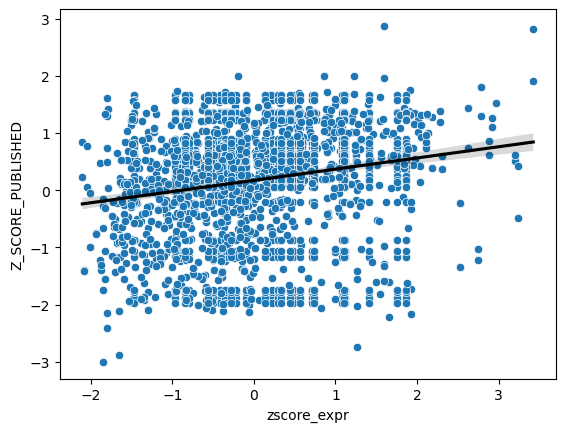

In [132]:


plt.figure() 
sbn.scatterplot(x='zscore_expr', y='Z_SCORE_PUBLISHED', data=df) 
sbn.regplot(x='zscore_expr', y='Z_SCORE_PUBLISHED', data=df, scatter=False, color='black')
plt.show() 

In [133]:
df__ = df[lambda x: x.CCLE_Name.str.contains('MCF7') \
    | x.CCLE_Name.str.contains('BT20') \
        | x.CCLE_Name.str.contains('MDAMB231') \
            | x.CCLE_Name.str.contains('T47D')][['DATASET', 'CCLE_Name', 'Z_SCORE_PUBLISHED', 'auc', 'zscore_expr', 'log_expr']]

df__.style.hide()

DATASET,CCLE_Name,Z_SCORE_PUBLISHED,auc,zscore_expr,log_expr
GDSC1,T47D_BREAST,1.176727,0.937388,0.325659,7.814230
GDSC2,T47D_BREAST,1.530974,0.933038,0.325659,7.814230
GDSC1,MDAMB231_BREAST,-0.586737,0.603333,-0.909179,5.969473
GDSC2,MDAMB231_BREAST,-0.472021,0.745774,-0.909179,5.969473
GDSC1,BT20_BREAST,0.180402,0.755402,-0.804830,6.125362
GDSC2,BT20_BREAST,0.194446,0.854801,-0.804830,6.125362
GDSC1,MCF7_BREAST,1.311511,0.976778,1.917008,10.191590
GDSC2,MCF7_BREAST,1.761750,nan,1.917008,10.191590


/tmp/ipykernel_379/1070496119.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = reg.pvalues[1]


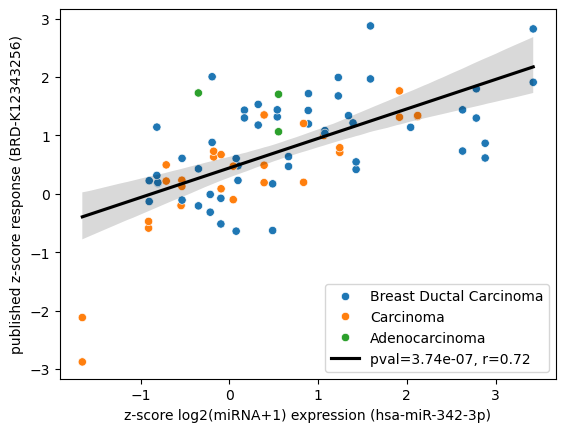

In [134]:
target_resp = 'Z_SCORE_PUBLISHED' 
target_expr = 'zscore_expr'
target_dataset = 'GDSC1'

#df_breast = df[lambda x: x.primary_disease == 'Breast Cancer'][['CCLE_Name', target_expr, target_resp]].dropna()
#df_breast = df_breast.groupby('CCLE_Name').mean()
df_breast = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)][[target_expr, target_resp]].dropna()

r_spearman = df_breast.corr(method='spearman').values[0, 1] 

reg = sm.OLS(df_breast[target_resp], sm.add_constant(df_breast[target_expr])).fit()
pval = reg.pvalues[1]


plt.figure() 
sbn.scatterplot(x=target_expr, y=target_resp, data=df[lambda x: x.primary_disease == 'Breast Cancer'], hue='Subtype') 
sbn.regplot(x=target_expr, y=target_resp, data=df[lambda x: x.primary_disease == 'Breast Cancer'], scatter=False, color='black', label=f'pval={pval:.2e}, r={r_spearman:.2f}')
plt.legend()
plt.xlabel(f'z-score log2(miRNA+1) expression ({target_mirna})')
plt.ylabel(f'published z-score response ({target_drug})')
plt.show() 

ValueError: Missing value(s) ['high'] for expr_cat (specified in `pairs`) in data.

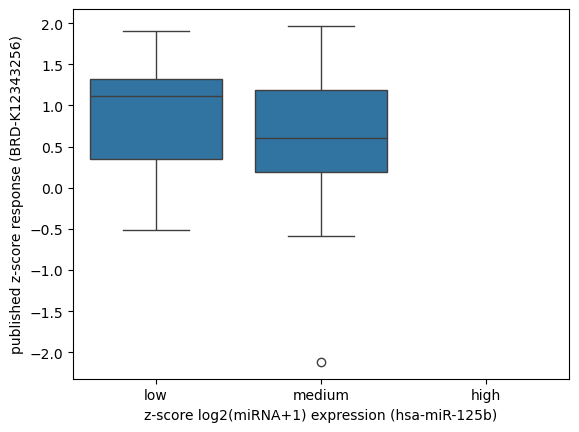

In [45]:
from statannotations.Annotator import Annotator

df_breast = df_breast.assign(expr_cat = lambda x: pd.cut(x[target_expr], bins=[-np.inf, -1, 1, np.inf], labels=['low', 'medium', 'high']))

plt.figure()
ax = sbn.boxplot(x='expr_cat', y=target_resp, data=df_breast)

plt.xlabel(f'z-score log2(miRNA+1) expression ({target_mirna})')
plt.ylabel(f'published z-score response ({target_drug})')

# Add significance annotations
pairs = [('low', 'medium'), ('medium', 'high'), ('low', 'high')]
annotator = Annotator(ax, pairs, data=df_breast, x='expr_cat', y=target_resp)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show() 

# distribution of correlations 

In [114]:
expr = pd.read_csv('~/local/data/ccle/CCLE_miRNA_20180525.gct', sep='\t', skiprows=2)
expr = expr.drop(columns=['Name']).set_index('Description').T.reset_index().rename(columns={'index': 'CCLE_Name'})
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'lineage', 'primary_disease', 'Subtype']].dropna()
expr = expr.merge(cell_info, left_on='CCLE_Name', right_on='CCLE_Name', how='left')

expr[expr.columns[1:-4]] = expr[expr.columns[1:-4]].apply(lambda x: np.log2(x + 1))
expr[expr.columns[1:-4]] = expr[expr.columns[1:-4]].apply(lambda x: (x - x.mean()) / x.std())

resp = pd.read_csv('~/local/data/ccle/sanger-dose-response.csv')
resp = resp[lambda x: x.BROAD_ID == target_drug]

df = expr.merge(resp, left_on='DepMap_ID', right_on='ARXSPAN_ID', how='left')

df = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)]


In [116]:
mirna_genes = [x for x in df.columns[df.columns.str.contains('hsa-')].tolist() if '+' not in x]

df2 = df[mirna_genes + ['Z_SCORE_PUBLISHED']].dropna()
corr_mat = df2.corr(method='spearman')

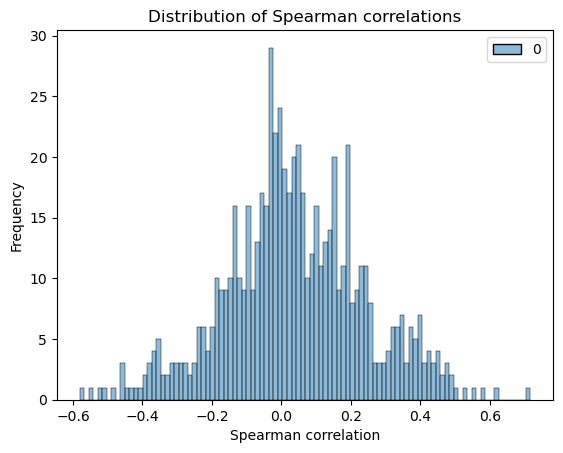

In [117]:
corrs_flat = corr_mat[['Z_SCORE_PUBLISHED']][lambda x: x.index != 'Z_SCORE_PUBLISHED'].values

plt.figure()
sbn.histplot(corrs_flat, bins=100)
plt.xlabel('Spearman correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Spearman correlations')
plt.show()


In [118]:
(corrs_flat < -0.36).mean() 

np.float64(0.032507739938080496)

In [123]:
(corrs_flat < 0.38).mean() 

np.float64(0.9411764705882353)

In [124]:
(corrs_flat < 0.41).mean() 

np.float64(0.958204334365325)

In [122]:
max_corr = corrs_flat.max() 

In [120]:
corr_mat.iloc[(corr_mat.values == max_corr).nonzero()]

,hsa-miR-890,Z_SCORE_PUBLISHED,hsa-let-7b,hsa-miR-342-3p
hsa-let-7b,0.716725,-0.073693,1.000000,0.296167
hsa-miR-342-3p,0.145819,0.716725,0.296167,1.000000
hsa-miR-890,1.000000,0.042857,0.716725,0.145819
Z_SCORE_PUBLISHED,0.042857,1.000000,-0.073693,0.716725
